In [1]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re

In [2]:
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

# 1. Default SimCLR

In [3]:
# Default SimCLR
default_models = {}

with open('results/model_eval/5561-resnet18_resize_33_default_eval.pkl', 'rb') as f:
    eval_resnet18 = pickle.load(f)

with open('results/model_details/5561-resnet18_resize_33_default_details.pkl', 'rb') as f:
    details_resnet18 = pickle.load(f)

default_models['ResNet18'] = {}
default_models['ResNet18']['KNN'] = eval_resnet18['euclidean'][10]
default_models['ResNet18']['time'] = details_resnet18['Training time w/o evaluation'] / details_resnet18['N_EPOCHS']

In [4]:
# equivariant SimCLR

for n in range(1, 11):
    if n == 9:
        continue
    eval_path = f'results/model_eval/1010-path_mnist-eqCLR_resnet18_N{n}_keepdim_params_resize33_eval.pkl'
    details_path = f'results/model_details/1010-path_mnist-eqCLR_resnet18_N{n}_keepdim_params_resize33_details.pkl'

    with open(eval_path, 'rb') as f:
        eval_eq_res = pickle.load(f)

    with open(details_path, 'rb') as f:
        details_eq_res = pickle.load(f)

    default_models[f'eqResNet_N={n}'] = {}
    default_models[f'eqResNet_N={n}']['KNN'] = eval_eq_res['euclidean'][10]
    default_models[f'eqResNet_N={n}']['time'] = details_eq_res['Training time w/o evaluation'] / details_eq_res['N_EPOCHS']


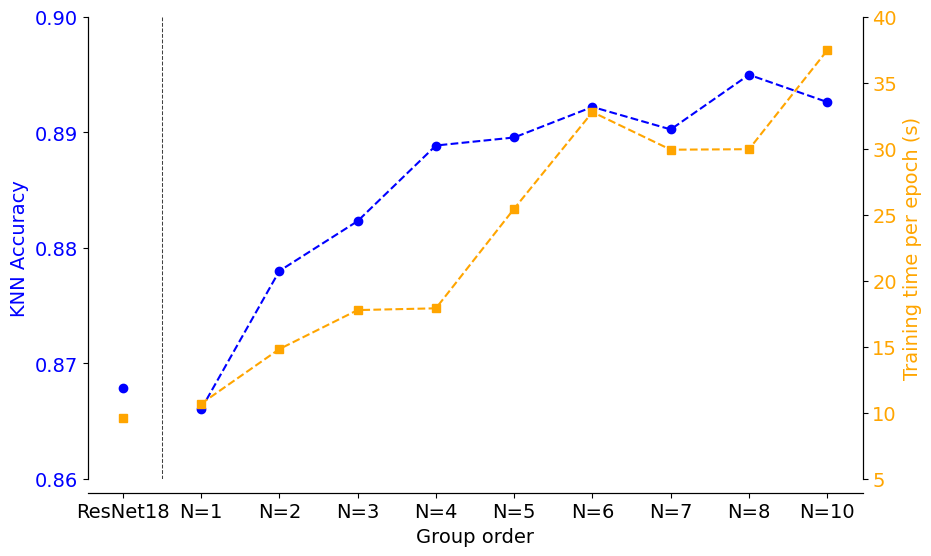

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
fontsize = 14

labels_eq = [f'N={n}' for n in range(1, 11) if n != 9]

ax.errorbar('ResNet18', default_models['ResNet18']['KNN'], fmt='o', color='blue')
ax.errorbar(labels_eq, [default_models[f'eqResNet_{label}']['KNN'] for label in labels_eq], fmt='--o', capsize=5, color='blue')

ax.set_ylabel('KNN Accuracy', color='blue', fontsize=fontsize)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax.set_ylim(0.86, 0.9)
ax.set_yticks([0.86, 0.87, 0.88, 0.89, 0.9])
ax.set_xlabel('Group order', fontsize=fontsize)

ax2 = ax.twinx()
ax2.errorbar('ResNet18', default_models['ResNet18']['time'], fmt='s', color='orange')
ax2.errorbar(labels_eq, [default_models[f'eqResNet_{label}']['time'] for label in labels_eq], fmt='--s', capsize=5, color='orange')

ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(5, 40)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='x', labelsize=fontsize)

ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))

# 2. Varying degree of equivariance

In [10]:
part_eq_models = {}

for n in range(5):
    knns = []
    times = []
    for seed in range(2):
        path_eval = f'results_rs/model_eval/6001_seed{seed}_path_mnist-mixed_eqCLR_resnet18_N4_{n}eqblocks_kp_eval.pkl'
        path_details = f'results_rs/model_details/6001_seed{seed}_path_mnist-mixed_eqCLR_resnet18_N4_{n}eqblocks_kp_details.pkl'

        with open(path_eval, 'rb') as f:
            eval_data = pickle.load(f)
        with open(path_details, 'rb') as f:
            details_data = pickle.load(f)

        knns.append(eval_data['euclidean'][10])
        times.append(details_data['Training time w/o evaluation'] / details_data['N_EPOCHS'])

    key = f'{n} eq. layer' if n in  [0, 1] else f'{n} eq. layers'
    part_eq_models[key] = {}
    part_eq_models[key]['KNN_mean'] = np.mean(knns)
    part_eq_models[key]['KNN_std'] = np.std(knns)
    part_eq_models[key]['time_mean'] = np.mean(times)
    part_eq_models[key]['time_std'] = np.std(times)

performance_df_cp = pd.DataFrame(part_eq_models).T
display(performance_df_cp)



,KNN_mean,KNN_std,time_mean,time_std
0 eq. layer,0.844638,0.002298,9.949327,0.056879
1 eq. layer,0.883217,0.000627,10.573255,0.090265
2 eq. layers,0.890181,0.002298,12.122194,0.054835
3 eq. layers,0.888301,0.002089,14.201632,0.013333
4 eq. layers,0.890529,0.000975,18.152584,0.004007


In [11]:
part_eq_models_ic = {}

for n in range(1, 5):
    knns = []
    times = []
    for seed in range(1):
        path_eval = f'results_rs/model_eval/7001_seed{seed}_path_mnist-mixed_eqCLR_resnet18_N4_{n}eqblocks_ic_eval.pkl'
        path_details = f'results_rs/model_details/7001_seed{seed}_path_mnist-mixed_eqCLR_resnet18_N4_{n}eqblocks_ic_details.pkl'

        with open(path_eval, 'rb') as f:
            eval_data = pickle.load(f)
        with open(path_details, 'rb') as f:
            details_data = pickle.load(f)

        knns.append(eval_data['euclidean'][10])
        times.append(details_data['Training time w/o evaluation'] / details_data['N_EPOCHS'])

    key = f'{n} eq. layer' if n in  [0, 1] else f'{n} eq. layers'
    part_eq_models_ic[key] = {}
    part_eq_models_ic[key]['KNN_mean'] = np.mean(knns)
    part_eq_models_ic[key]['KNN_std'] = np.std(knns)
    part_eq_models_ic[key]['time_mean'] = np.mean(times)
    part_eq_models_ic[key]['time_std'] = np.std(times)

performance_df_ic = pd.DataFrame(part_eq_models_ic).T
display(performance_df_ic)



,KNN_mean,KNN_std,time_mean,time_std
1 eq. layer,0.885376,0.0,14.747016,0.0
2 eq. layers,0.894568,0.0,20.547278,0.0
3 eq. layers,0.897772,0.0,28.912329,0.0
4 eq. layers,0.900279,0.0,45.969516,0.0


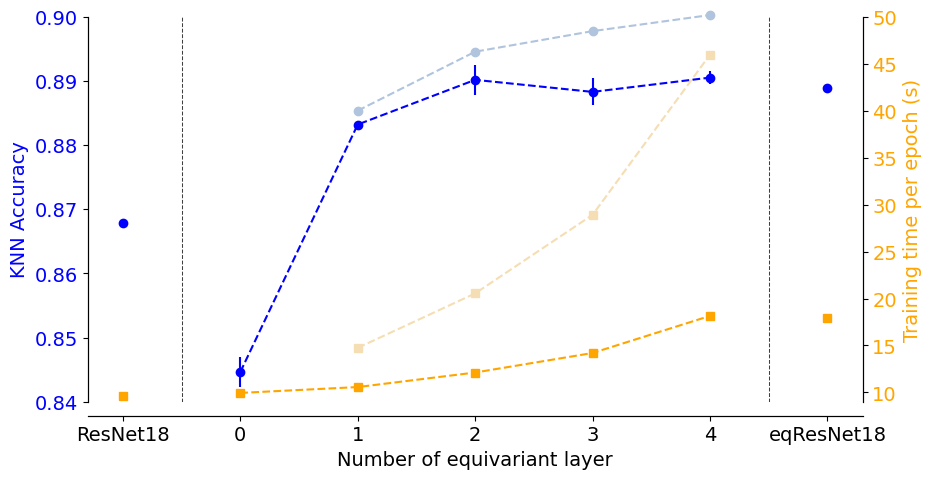

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

fontsize = 14
ax.errorbar('ResNet18', default_models['ResNet18']['KNN'], fmt='o', label='KNN Accuracy', color='blue', clip_on=False)
labels = [0, 1, 2, 3, 4]
labels = [str(x) for x in labels]
ax.errorbar(labels, performance_df_cp['KNN_mean'], yerr=performance_df_cp['KNN_std'], fmt='o--', label='KNN Accuracy', color='blue', clip_on=False)

labels_ic = [1, 2, 3, 4]
labels_ic = [str(x) for x in labels_ic]
ax.errorbar(labels_ic, performance_df_ic['KNN_mean'], yerr=performance_df_ic['KNN_std'], fmt='o--', label='KNN Accuracy', color='lightsteelblue', clip_on=False)

ax.errorbar('eqResNet18', default_models['eqResNet_N=4']['KNN'], fmt='o', label='KNN Accuracy', color='blue', clip_on=False)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

ax.set_xlabel('Number of equivariant layer', fontsize=fontsize)
ax.set_ylabel('KNN Accuracy', fontsize=fontsize, color='blue')
ax.set_ylim(0.84, 0.9)
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)


ax2 = ax.twinx()
ax2.errorbar('ResNet18', default_models['ResNet18']['time'], fmt='s--', label='Training Time per Epoch', color='orange', clip_on=False)
ax2.errorbar(labels, performance_df_cp['time_mean'], yerr=performance_df_cp['time_std'], fmt='s--', color='orange', label='Training Time per Epoch', clip_on=False)
ax2.errorbar(labels_ic, performance_df_ic['time_mean'], yerr=performance_df_ic['time_std'], fmt='s--', color='wheat', label='Training Time per Epoch', clip_on=False)

ax2.errorbar('eqResNet18', default_models['eqResNet_N=4']['time'], fmt='s', label='KNN Accuracy', color='orange', clip_on=False)
ax2.axvline(5.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)

ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(9, 50)
#ax2.set_yticks([9, 11, 13, 15, 17, 19])

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))


# 3. Equivariant encoder

In [12]:
eqEncoder_models = {}

for c in [3, 8, 16, 32, 64, 128]:
    knns = []
    times = []
    for seed in [0]:
        path_eval = f'results_rs/model_eval/6005-seed{seed}_path_mnist-eqEncoder_{c}c_N4_Resnet18_eval.pkl'
        path_details = f'results_rs/model_details/6005-seed{seed}_path_mnist-eqEncoder_{c}c_N4_Resnet18_details.pkl'

        with open(path_eval, 'rb') as f:
            eval_data = pickle.load(f)
        with open(path_details, 'rb') as f:
            details_data = pickle.load(f)

        knns.append(eval_data['euclidean'][10])
        times.append(details_data['Training time w/o evaluation'] / details_data['N_EPOCHS'])

    key = f'eqEncoder_{c}c'
    eqEncoder_models[key] = {}
    eqEncoder_models[key]['KNN_mean'] = np.mean(knns)
    eqEncoder_models[key]['KNN_std'] = np.std(knns)
    eqEncoder_models[key]['time_mean'] = np.mean(times)
    eqEncoder_models[key]['time_std'] = np.std(times)

performance_df = pd.DataFrame(eqEncoder_models).T
display(performance_df)

,KNN_mean,KNN_std,time_mean,time_std
eqEncoder_3c,0.868802,0.0,9.431690,0.0
eqEncoder_8c,0.873677,0.0,10.037814,0.0
eqEncoder_16c,0.871031,0.0,11.641613,0.0
eqEncoder_32c,0.870752,0.0,13.687015,0.0
eqEncoder_64c,0.866156,0.0,18.325763,0.0
eqEncoder_128c,0.872145,0.0,28.685348,0.0


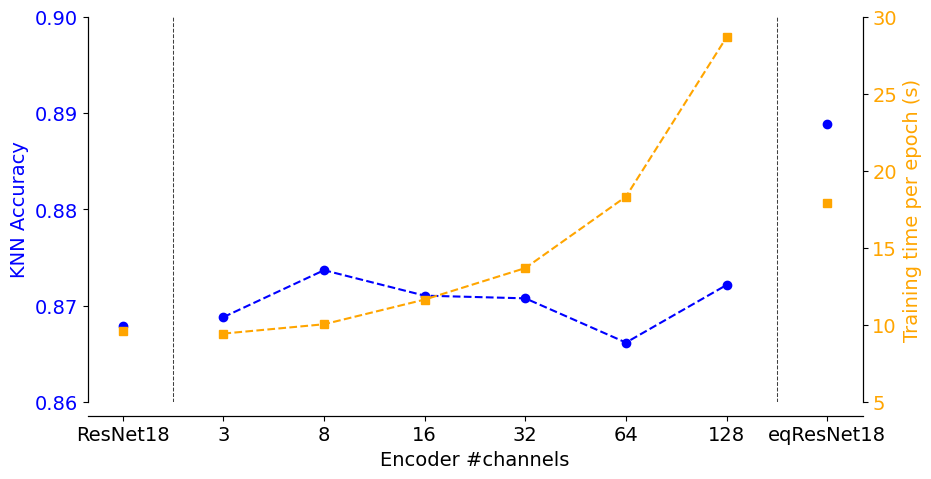

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

fontsize = 14
ax.errorbar('ResNet18', default_models['ResNet18']['KNN'], fmt='o', label='KNN Accuracy', color='blue', clip_on=False, zorder=5)
labels = [3, 8, 16, 32, 64, 128]
labels = [str(x) for x in labels]
ax.errorbar(labels, [eqEncoder_models[f'eqEncoder_{c}c']['KNN_mean'] for c in labels], fmt='o--', label='KNN Accuracy', color='blue', clip_on=False, zorder=5)
ax.errorbar('eqResNet18', default_models['eqResNet_N=4']['KNN'], fmt='o', label='KNN Accuracy', color='blue', clip_on=False)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)


ax.set_xlabel('Encoder #channels', fontsize=fontsize)
ax.set_ylabel('KNN Accuracy', fontsize=fontsize, color='blue')
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)
ax.set_ylim(0.86, 0.9)
ax.set_yticks([0.86, 0.87, 0.88, 0.89, 0.9])

ax2 = ax.twinx()
ax2.errorbar('ResNet18', default_models['ResNet18']['time'], fmt='s--', label='Training Time per Epoch', color='orange', clip_on=False, zorder=-1)
ax2.errorbar(labels, [eqEncoder_models[f'eqEncoder_{c}c']['time_mean'] for c in labels], yerr=[eqEncoder_models[f'eqEncoder_{c}c']['time_std'] for c in labels], fmt='s--', color='orange', label='Training Time per Epoch', clip_on=False, zorder=-1)
ax2.errorbar('eqResNet18', default_models['eqResNet_N=4']['time'], fmt='s', label='KNN Accuracy', color='orange', clip_on=False)
ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
ax2.set_ylim(5, 30)
# ax2.set_yticks([9, 11, 13, 15, 17, 19])
ax.axvline(6.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)


ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))



# 4. SimCLR averaged rotations 

In [18]:
avg_rot_models_no_train = {}

for v in [1, 2, 4, 8, 12, 16]: # [3, 8, 16, 32, 64, 128]
    knns = []
    #times = []
    for seed in [0]:
        path_eval = f'results_rs/model_eval/2002_seed{seed}_resnet18_views{v}x_no_train_100epochs_eval.pkl'
        # path_details = f'results_rs/model_eval/2002_seed{seed}_resnet18_views{v}x_no_train_100epochs_eval.pkl'

        with open(path_eval, 'rb') as f:
            eval_data = pickle.load(f)
        # with open(path_details, 'rb') as f:
        #     details_data = pickle.load(f)

        knns.append(eval_data['euclidean'][10])
        #times.append(details_data['Training time w/o evaluation'] / details_data['N_EPOCHS'])

    key = f'SimCLR_{v}x_views'
    avg_rot_models_no_train[key] = {}
    avg_rot_models_no_train[key]['KNN_mean'] = np.mean(knns)
    avg_rot_models_no_train[key]['KNN_std'] = np.std(knns)
    # avg_rot_models_no_train[key]['time_mean'] = np.mean(times)
    # avg_rot_models_no_train[key]['time_std'] = np.std(times)

performance_df = pd.DataFrame(avg_rot_models_no_train).T
display(performance_df)

,KNN_mean,KNN_std
SimCLR_1x_views,0.867827,0.0
SimCLR_2x_views,0.869777,0.0
SimCLR_4x_views,0.869359,0.0
SimCLR_8x_views,0.869638,0.0
SimCLR_12x_views,0.866713,0.0
SimCLR_16x_views,0.864763,0.0


In [19]:
for v in [1, 2, 4, 8]: # [3, 8, 16, 32, 64, 128]
    knns = []
    times = []
    for seed in [0]:
        path_eval = f'results_rs/model_eval/2003_seed{seed}_resnet18_views{v}x_with_train_100epochs_eval.pkl'
        path_details = f'results_rs/model_details/2003_seed{seed}_resnet18_views{v}x_with_train_100epochs_details.pkl'

        with open(path_eval, 'rb') as f:
            eval_data = pickle.load(f)
        with open(path_details, 'rb') as f:
            details_data = pickle.load(f)

        knns.append(eval_data['euclidean'][10])
        times.append(details_data['Training time w/o evaluation'] / details_data['N_EPOCHS'])

    key = f'SimCLR_{v}x_views_trained'
    avg_rot_models_no_train[key] = {}
    avg_rot_models_no_train[key]['KNN_mean'] = np.mean(knns)
    avg_rot_models_no_train[key]['KNN_std'] = np.std(knns)
    avg_rot_models_no_train[key]['time_mean'] = np.mean(times)
    avg_rot_models_no_train[key]['time_std'] = np.std(times)

performance_df = pd.DataFrame(avg_rot_models_no_train).T
display(performance_df)

,KNN_mean,KNN_std,time_mean,time_std
SimCLR_1x_views,0.867827,0.0,NaN,NaN
SimCLR_2x_views,0.869777,0.0,NaN,NaN
SimCLR_4x_views,0.869359,0.0,NaN,NaN
SimCLR_8x_views,0.869638,0.0,NaN,NaN
SimCLR_12x_views,0.866713,0.0,NaN,NaN
SimCLR_16x_views,0.864763,0.0,NaN,NaN
SimCLR_1x_views_trained,0.868106,0.0,9.129578,0.0
SimCLR_2x_views_trained,0.876323,0.0,12.851807,0.0
SimCLR_4x_views_trained,0.883148,0.0,22.501564,0.0
SimCLR_8x_views_trained,0.863092,0.0,42.871903,0.0


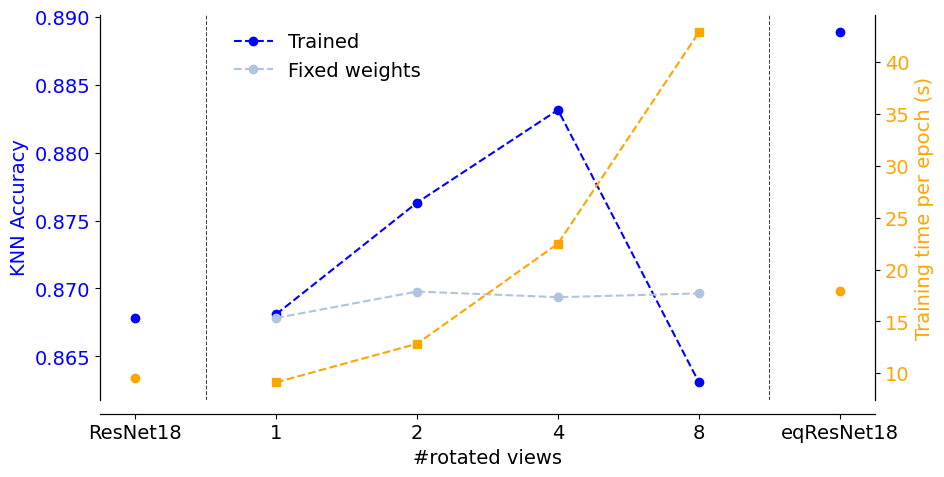

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

fontsize = 14
ax.errorbar('ResNet18', default_models['ResNet18']['KNN'], fmt='o', color='blue', clip_on=False)
labels = [1, 2, 4, 8]
labels = [str(x) for x in labels]
ax.errorbar(labels, [avg_rot_models_no_train[f'SimCLR_{c}x_views_trained']['KNN_mean'] for c in labels], fmt='o--', label='Trained', color='blue', clip_on=False)
ax.errorbar(labels, [avg_rot_models_no_train[f'SimCLR_{c}x_views']['KNN_mean'] for c in labels], fmt='o--', label='Fixed weights', color='lightsteelblue', clip_on=False)

ax.errorbar('eqResNet18', default_models['eqResNet_N=4']['KNN'], fmt='o', color='blue', clip_on=False)
ax.axvline(0.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)
ax.legend(loc='upper left', bbox_to_anchor=(0.15, 1.0), fontsize=fontsize, frameon=False)

ax.set_xlabel('#rotated views', fontsize=fontsize)
ax.set_ylabel('KNN Accuracy', fontsize=fontsize, color='blue')
ax.tick_params(axis='y', labelcolor='blue', labelsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)

ax2 = ax.twinx()
ax2.errorbar('ResNet18', default_models['ResNet18']['time'], fmt='o--', label='Training Time per Epoch', color='orange', clip_on=False)
ax2.errorbar(labels, [avg_rot_models_no_train[f'SimCLR_{c}x_views_trained']['time_mean'] for c in labels], yerr=[avg_rot_models_no_train[f'SimCLR_{c}x_views_trained']['time_std'] for c in labels], fmt='s--', color='orange', label='Training Time per Epoch', clip_on=False)
ax2.errorbar('eqResNet18', default_models['eqResNet_N=4']['time'], fmt='o', label='KNN Accuracy', color='orange', clip_on=False)
ax2.set_ylabel('Training time per epoch (s)', color='orange', fontsize=fontsize)
ax2.tick_params(axis='y', labelcolor='orange', labelsize=fontsize)
# ax2.set_ylim(9, 19)
# ax2.set_yticks([9, 11, 13, 15, 17, 19])
ax.axvline(4.5, linestyle='--', linewidth=0.75, alpha=0.75, color='black', zorder=1)


ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 10))